In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from scipy.stats import chi2_contingency

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [112]:
# data load
df = pd.read_csv('Data_Polis.csv')

print("Data Polis")
display(df.head()) 

print("\ndata info")
print(df.info())

# data load 2
df2 = pd.read_csv('Data_Klaim.csv')

print("\nData Klaim")
display(df2.head())

print("\ndata info")
print(df2.info())

Data Polis


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nomor Polis            4096 non-null   object
 1   Plan Code              4096 non-null   object
 2   Gender                 4096 non-null   object
 3   Tanggal Lahir          4096 non-null   int64 
 4   Tanggal Efektif Polis  4096 non-null   int64 
 5   Domisili               4096 non-null   object
dtypes: int64(2), object(4)
memory usage: 192.1+ KB
None

Data Klaim


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore



data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       4627 non-null   object 
 1   Nomor Polis                    4627 non-null   object 
 2   Reimburse/Cashless             4627 non-null   object 
 3   Inpatient/Outpatient           4590 non-null   object 
 4   ICD Diagnosis                  4621 non-null   object 
 5   ICD Description                4621 non-null   object 
 6   Status Klaim                   4627 non-null   object 
 7   Tanggal Pembayaran Klaim       4590 non-null   object 
 8   Tanggal Pasien Masuk RS        4627 non-null   object 
 9   Tanggal Pasien Keluar RS       4627 non-null   object 
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64
 11  Nominal Biaya RS Yang Terjadi  4627 non-null   float64
 12  Lokasi RS                      4620 n

In [113]:
df['Tanggal Lahir'] = pd.to_datetime(df['Tanggal Lahir'], format='%Y%m%d')
df['Tanggal Efektif Polis'] = pd.to_datetime(df['Tanggal Efektif Polis'], format='%Y%m%d')

df2['Tanggal Pembayaran Klaim'] = pd.to_datetime(df2['Tanggal Pembayaran Klaim'])
df2['Tanggal Pasien Masuk RS'] = pd.to_datetime(df2['Tanggal Pasien Masuk RS'])
df2['Tanggal Pasien Keluar RS'] = pd.to_datetime(df2['Tanggal Pasien Keluar RS'])

df.dtypes
df2.dtypes

Claim ID                                 object
Nomor Polis                              object
Reimburse/Cashless                       object
Inpatient/Outpatient                     object
ICD Diagnosis                            object
ICD Description                          object
Status Klaim                             object
Tanggal Pembayaran Klaim         datetime64[ns]
Tanggal Pasien Masuk RS          datetime64[ns]
Tanggal Pasien Keluar RS         datetime64[ns]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                object
dtype: object


Missing value Data Polis
Series([], dtype: int64)


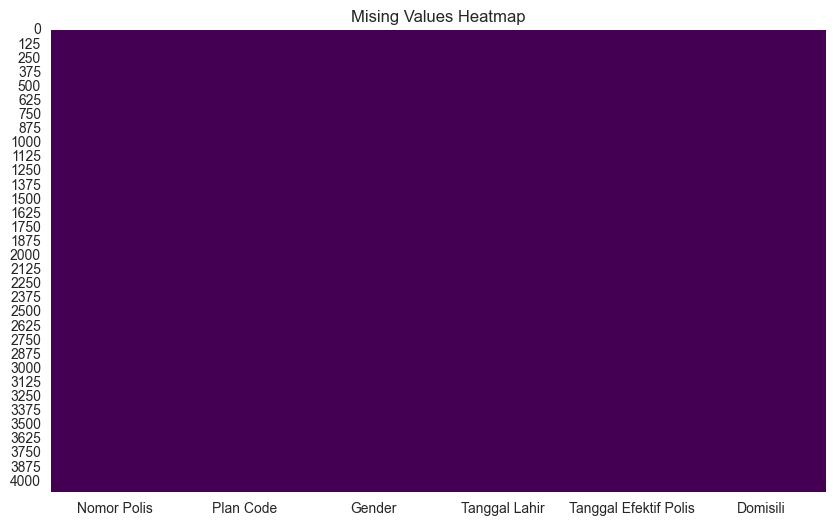


Missing value Data Klaim
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


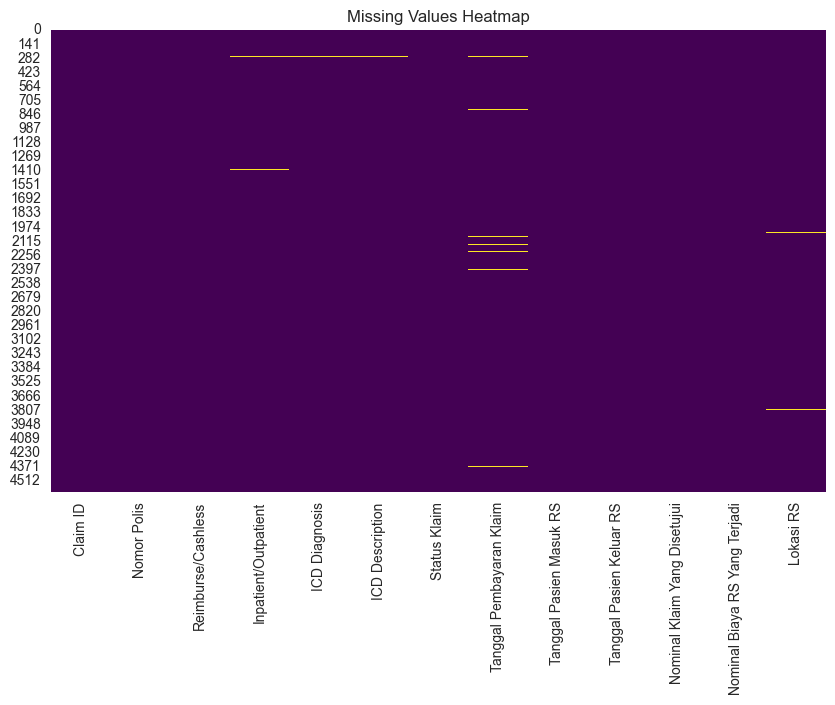

In [114]:
# missing value data polis
print("\nMissing value Data Polis")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

# missing value data klaim
print("\nMissing value Data Klaim")
missing_values = df2.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df2.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [115]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


In [116]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')

display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0


In [117]:
# Separasi Dataset
# Cluster Check untuk severity
cluster_check = df_final[df_final['Inpatient/Outpatient'].isnull() & df_final['Tanggal Pembayaran Klaim'].isnull()]
print(f"Jumlah baris dalam cluster masalah: {len(cluster_check)}")

# Dataset Severity (hanya klaim yang terjadi)
df_severity = df_final[df_final['is_claim'] == 1].copy()

# Bersihkan cluster 37 baris di data severity karena akan merusak akurasi fitur medis
df_severity = df_severity.dropna(subset=['Inpatient/Outpatient', 'ICD Diagnosis'])

# Dataset FREKUENSI 
df_frequency = df_final.copy()

print(f"Ukuran Data Severity: {df_severity.shape}")
print(f"Ukuran Data Frequency: {df_frequency.shape}")

Jumlah baris dalam cluster masalah: 0
Ukuran Data Severity: (4627, 19)
Ukuran Data Frequency: (7513, 19)


Baris sebelum drop usia negatif : 4627
Baris setelah drop usia negatif : 4627

Statistik Usia Severity:
count    4627.000000
mean       59.346490
std        12.567030
min         6.795346
25%        51.438741
50%        59.947981
75%        68.939083
max        90.324435
Name: Usia_Saat_Klaim, dtype: float64


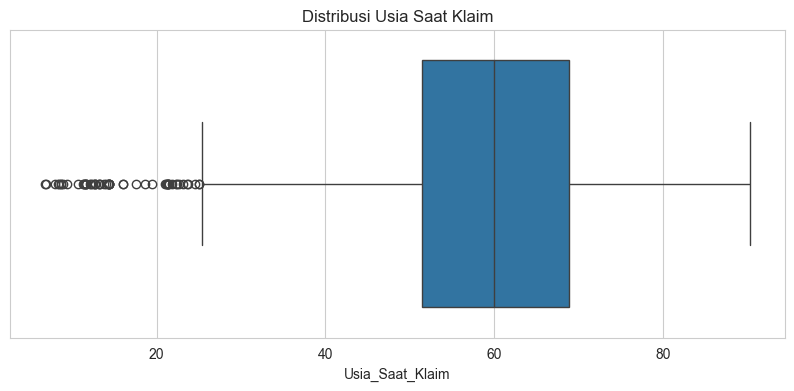

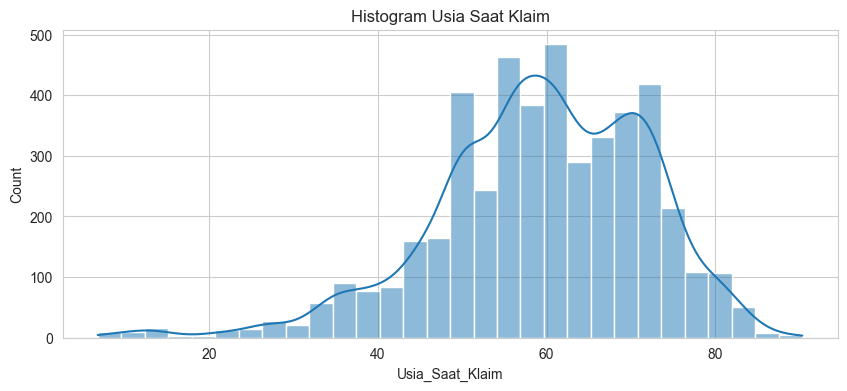

In [118]:
# Feature Engineering & Data Validation AGE)

# Hitung usia
df_severity['Usia_Saat_Klaim'] = (
    (df_severity['Tanggal Pasien Masuk RS'] - df_severity['Tanggal Lahir']).dt.days / 365.25
)

# handle usia negatif (data error)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Usia_Saat_Klaim'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum drop usia negatif : {before_rows}")
print(f"Baris setelah drop usia negatif : {after_rows}")

# Cap outlier biologis menggunakan batas logis 100 tahun
upper_cap = 100
outlier_count = (df_severity['Usia_Saat_Klaim'] > upper_cap).sum()

if outlier_count > 0:
    print(f"Ditemukan {outlier_count} usia > {upper_cap}. Akan di-cap.")
    df_severity.loc[
        df_severity['Usia_Saat_Klaim'] > upper_cap,
        'Usia_Saat_Klaim'
    ] = upper_cap

# BINNING USIA

age_bins = [0, 12, 18, 45, 65, 100]
age_labels = ['Anak', 'Remaja', 'Dewasa', 'Lansia_Awal', 'Lansia_Akhir']

df_severity['Kategori_Usia'] = pd.cut(
    df_severity['Usia_Saat_Klaim'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# USIA NASABAH (FREQUENCY)

ref_date = df_frequency['Tanggal Efektif Polis'].max()

df_frequency['Tanggal Lahir'] = pd.to_datetime(df_frequency['Tanggal Lahir'])

df_frequency['Usia_Nasabah'] = (
    (ref_date - df_frequency['Tanggal Lahir']).dt.days / 365.25
)

# Handle usia negatif 
df_frequency = df_frequency[df_frequency['Usia_Nasabah'] >= 0].copy()

# VISUALISASI
print("\nStatistik Usia Severity:")
print(df_severity['Usia_Saat_Klaim'].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x=df_severity['Usia_Saat_Klaim'])
plt.title('Distribusi Usia Saat Klaim')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_severity['Usia_Saat_Klaim'], bins=30, kde=True)
plt.title('Histogram Usia Saat Klaim')
plt.show()

In [119]:
# Hitung Length of Stay & Bersihkan Error

# Hitung LOS
df_severity['Lama_Inap'] = (
    df_severity['Tanggal Pasien Keluar RS'] -
    df_severity['Tanggal Pasien Masuk RS']
).dt.days

# Hapus error tanggal (keluar < masuk)
before_rows = len(df_severity)
df_severity = df_severity[df_severity['Lama_Inap'] >= 0].copy()
after_rows = len(df_severity)

print(f"Baris sebelum : {before_rows}")
print(f"Baris setelah : {after_rows}")

print(df_severity['Lama_Inap'].describe())

Baris sebelum : 4627
Baris setelah : 4627
count    4627.000000
mean        1.264102
std         2.930572
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        54.000000
Name: Lama_Inap, dtype: float64


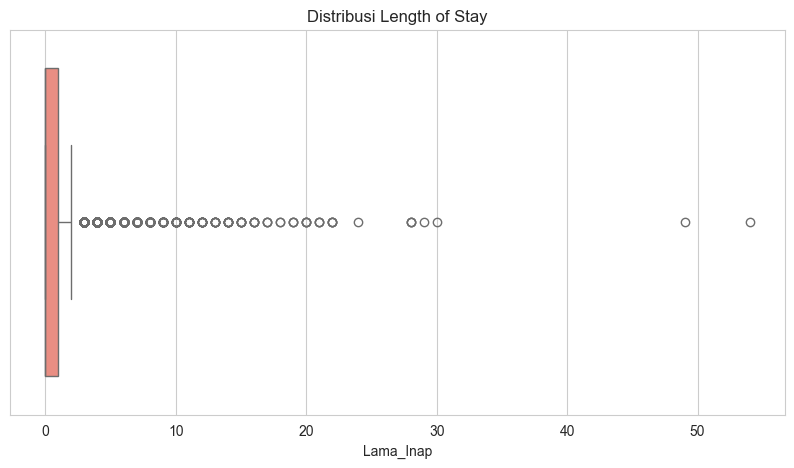

Detail LOS 54 Hari:


,Nomor Polis,ICD Description,Nominal Biaya RS Yang Terjadi,Inpatient/Outpatient
1368,POL-0830,"MALIGNANT NEOPLASM, BRONCHUS OR LUNG, UNSPECIFIED",1.465628e+09,IP


In [120]:
# Cek Outlier 54 Hari

plt.figure(figsize=(10,5))
sns.boxplot(x=df_severity['Lama_Inap'], color='salmon')
plt.title('Distribusi Length of Stay')
plt.show()

# Investigasi LOS 54 hari
outlier_54 = df_severity[df_severity['Lama_Inap'] == 54]

print("Detail LOS 54 Hari:")
display(outlier_54[['Nomor Polis',
                    'ICD Description',
                    'Nominal Biaya RS Yang Terjadi',
                    'Inpatient/Outpatient']])

In [121]:
# Feature Final LOS

# Dummy outpatient
df_severity['Is_Outpatient'] = (df_severity['Lama_Inap'] == 0).astype(int)

# Adjusted LOS (untuk hindari log(0))
df_severity['Lama_Inap_Adj'] = df_severity['Lama_Inap'] + 1

# Optional: Capping 99% (tidak akan menghapus 54 jika masih dalam batas)
los_cap = df_severity['Lama_Inap'].quantile(0.99)

df_severity['Lama_Inap_Capped'] = np.where(
    df_severity['Lama_Inap'] > los_cap,
    los_cap,
    df_severity['Lama_Inap']
)

print(f"99th percentile: {los_cap}")

print("\nStatistik Final:")
print(df_severity[['Lama_Inap','Lama_Inap_Capped']].describe())

99th percentile: 13.0

Statistik Final:
         Lama_Inap  Lama_Inap_Capped
count  4627.000000       4627.000000
mean      1.264102          1.192998
std       2.930572          2.401121
min       0.000000          0.000000
25%       0.000000          0.000000
50%       0.000000          0.000000
75%       1.000000          1.000000
max      54.000000         13.000000


In [122]:
# Feature Engineering (SEASONALITY) 

# 1 ENSURE DATETIME
df_severity['Tanggal Pasien Masuk RS'] = pd.to_datetime(
    df_severity['Tanggal Pasien Masuk RS']
)

# 2 BASIC TIME FEATURES
df_severity['Tahun_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.year
df_severity['Bulan_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.month
df_severity['Hari_Masuk'] = df_severity['Tanggal Pasien Masuk RS'].dt.dayofweek
df_severity['Tanggal'] = df_severity['Tanggal Pasien Masuk RS'].dt.day

# 3 PERIODE BULANAN 
df_severity['Periode_Klaim'] = (
    df_severity['Tanggal Pasien Masuk RS'].dt.to_period('M')
)

# 4 QUARTER FEATURE 
df_severity['Quarter'] = df_severity['Tanggal Pasien Masuk RS'].dt.quarter

# 5 WEEKEND FLAG 
df_severity['Is_Weekend'] = (
    df_severity['Hari_Masuk'].isin([5,6])
).astype(int)

# 6 CYCLICAL ENCODING BULAN 
df_severity['Bulan_sin'] = np.sin(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

df_severity['Bulan_cos'] = np.cos(
    2 * np.pi * df_severity['Bulan_Masuk'] / 12
)

# 7 VALIDASI 
print("Fitur seasonality berhasil dibuat.\n")

display(
    df_severity[[
        'Periode_Klaim',
        'Tahun_Masuk',
        'Bulan_Masuk',
        'Quarter',
        'Hari_Masuk',
        'Is_Weekend'
    ]].head()
)

Fitur seasonality berhasil dibuat.



,Periode_Klaim,Tahun_Masuk,Bulan_Masuk,Quarter,Hari_Masuk,Is_Weekend
2,2024-09,2024,9,3,0,0
5,2024-08,2024,8,3,4,0
6,2024-10,2024,10,4,2,0
10,2024-01,2024,1,1,4,0
11,2024-01,2024,1,1,3,0


In [123]:
# CELL REPORT: Claim Portfolio Summary 

# 1 Basic Metrics
total_claim = len(df_severity)
unique_policy_claim = df_severity['Nomor Polis'].nunique()
total_policy = df_frequency['Nomor Polis'].nunique()

avg_claim_per_policy = total_claim / unique_policy_claim

percentage_with_claim = (unique_policy_claim / total_policy) * 100
percentage_without_claim = ((total_policy - unique_policy_claim) / total_policy) * 100

# 2 DataFrame Report
df_claim_report = pd.DataFrame({
    'Total_Polis_Portfolio': [total_policy],
    'Total_Klaim': [total_claim],
    'Polis_Pernah_Klaim': [unique_policy_claim],
    'Polis_Tidak_Pernah_Klaim': [total_policy - unique_policy_claim],
    'Rata2_Klaim_per_Polis_Klaim': [round(avg_claim_per_policy, 2)],
    'Persentase_Polis_Pernah_Klaim (%)': [round(percentage_with_claim, 2)],
    'Persentase_Polis_Tidak_Klaim (%)': [round(percentage_without_claim, 2)]
})

display(df_claim_report)

,Total_Polis_Portfolio,Total_Klaim,Polis_Pernah_Klaim,Polis_Tidak_Pernah_Klaim,Rata2_Klaim_per_Polis_Klaim,Persentase_Polis_Pernah_Klaim (%),Persentase_Polis_Tidak_Klaim (%)
0,4096,4627,1210,2886,3.82,29.54,70.46


In [124]:
import pandas as pd
import numpy as np

# ==============================
# 1. AGREGASI BULANAN
# ==============================
df_monthly = df_severity.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

# Jika Periode_Klaim bertipe Period, gunakan ini:
if isinstance(df_monthly['Periode_Klaim'].dtype, pd.PeriodDtype):
    df_monthly['Periode_Klaim'] = df_monthly['Periode_Klaim'].dt.to_timestamp()
else:
    df_monthly['Periode_Klaim'] = pd.to_datetime(df_monthly['Periode_Klaim'])

df_monthly = df_monthly.sort_values('Periode_Klaim')

# ==============================
# 2. PADDING BULAN HILANG
# ==============================
all_months = pd.date_range(
    start=df_monthly['Periode_Klaim'].min(),
    end=df_monthly['Periode_Klaim'].max(),
    freq='MS'
)

df_monthly = (
    df_monthly.set_index('Periode_Klaim')
    .reindex(all_months)
    .rename_axis('Periode_Klaim')
    .reset_index()
)

df_monthly['Total_Claim'] = df_monthly['Total_Claim'].fillna(0)

# ==============================
# 3. FEATURE ENGINEERING
# ==============================

# Lag 1
df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)

# Rolling mean 6 bulan (ANTI LEAKAGE)
df_monthly['Recent_Mean_6'] = (
    df_monthly['Total_Claim']
    .shift(1)
    .rolling(6)
    .mean()
)

# Time index (trend)
df_monthly['Time_Index'] = np.arange(len(df_monthly))

# Cyclical month
df_monthly['Month'] = df_monthly['Periode_Klaim'].dt.month
df_monthly['Month_sin'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Month_cos'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Drop NA akibat lag/rolling
df_monthly = df_monthly.dropna().reset_index(drop=True)

In [125]:
print (df_monthly.head())

# Cek tanggal awal dan akhir di data bulanan
print("--- Rentang Waktu Data Bulanan ---")
print("Tanggal Terawal:", df_monthly['Periode_Klaim'].min())
print("Tanggal Terbaru:", df_monthly['Periode_Klaim'].max())

# Cek jumlah bulan yang tersedia
total_bulan = len(df_monthly)
print(f"Total Observasi: {total_bulan} bulan")

  Periode_Klaim  Claim_Frequency   Total_Claim   Total_Lag_1  Recent_Mean_6  \
0    2024-07-01              257  1.497052e+10  1.212517e+10   1.403493e+10   
1    2024-08-01              228  1.351294e+10  1.497052e+10   1.315319e+10   
2    2024-09-01              208  1.226412e+10  1.351294e+10   1.309540e+10   
3    2024-10-01              274  1.268117e+10  1.226412e+10   1.275421e+10   
4    2024-11-01              270  1.373306e+10  1.268117e+10   1.296089e+10   

   Time_Index  Month  Month_sin     Month_cos  
0           6      7  -0.500000 -8.660254e-01  
1           7      8  -0.866025 -5.000000e-01  
2           8      9  -1.000000 -1.836970e-16  
3           9     10  -0.866025  5.000000e-01  
4          10     11  -0.500000  8.660254e-01  
--- Rentang Waktu Data Bulanan ---
Tanggal Terawal: 2024-07-01 00:00:00
Tanggal Terbaru: 2025-07-01 00:00:00
Total Observasi: 13 bulan


In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error

# ==============================
# 4. SETUP FEATURES
# ==============================

features = [
    'Total_Lag_1',
    'Recent_Mean_6',
    'Time_Index',
    'Month_sin',
    'Month_cos'
]

# Time-based split (5 bulan terakhir validasi)
train = df_monthly.iloc[:-5]
valid = df_monthly.iloc[-5:]

X_train = train[features]
y_train = train['Total_Claim']

X_valid = valid[features]
y_valid = valid['Total_Claim']

# Log transform
y_train_log = np.log1p(y_train)

# ==============================
# 5. ALPHA TUNING
# ==============================

print("=== 🎯 TUNING RIDGE (LOG SPACE) ===")

best_alpha = None
best_mape = 999

for a in [10, 20, 30, 40, 60, 80, 100]:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a, solver="svd"))
    ])
    
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_valid)
    y_pred = np.expm1(y_pred_log)
    
    mape = mean_absolute_percentage_error(y_valid, y_pred)
    print(f"Alpha {a} → MAPE: {mape:.4f}")
    
    if mape < best_mape:
        best_mape = mape
        best_alpha = a

print(f"\n🏆 BEST ALPHA: {best_alpha}")
print(f"📉 BEST MAPE: {best_mape:.4f}")

=== 🎯 TUNING RIDGE (LOG SPACE) ===


Alpha 10 → MAPE: 0.1044
Alpha 20 → MAPE: 0.0890
Alpha 30 → MAPE: 0.0819
Alpha 40 → MAPE: 0.0778
Alpha 60 → MAPE: 0.0752
Alpha 80 → MAPE: 0.0741
Alpha 100 → MAPE: 0.0733

🏆 BEST ALPHA: 100
📉 BEST MAPE: 0.0733


In [127]:
# ==========================================
# 1. FINAL MODEL FIT (FULL 19 MONTHS DATA)
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=100, solver="svd"))
])

# Ambil semua data tanpa dipotong (Total 19 baris)
X_full = df_monthly[features]
y_full_log = np.log1p(df_monthly['Total_Claim'])

final_model.fit(X_full, y_full_log)

# ==========================================
# 2. RECURSIVE FORECAST 17 BULAN
# ==========================================
df_future = df_monthly.copy()
future_predictions = []

for i in range(17):
    last_row = df_future.iloc[-1]
    next_date = last_row['Periode_Klaim'] + pd.DateOffset(months=1)
    
    # Feature Engineering untuk baris baru
    new_row = {
        'Periode_Klaim': next_date,
        'Time_Index': last_row['Time_Index'] + 1,
        'Month_sin': np.sin(2 * np.pi * next_date.month / 12),
        'Month_cos': np.cos(2 * np.pi * next_date.month / 12),
        'Total_Lag_1': last_row['Total_Claim'],
        'Recent_Mean_6': df_future['Total_Claim'].tail(6).mean()
    }
    
    # Prediksi
    X_new = pd.DataFrame([new_row])[features]
    pred_log = final_model.predict(X_new)
    pred_actual = np.expm1(pred_log)[0]
    
    # Guardrail (Optional: Biar juri nggak kaget kalau ada lonjakan)
    # pred_actual = np.clip(pred_actual, last_row['Total_Claim']*0.7, last_row['Total_Claim']*1.3)
    
    new_row['Total_Claim'] = pred_actual
    future_predictions.append(new_row)
    
    # Masukkan ke df_future untuk referensi loop berikutnya
    df_future = pd.concat([df_future, pd.DataFrame([new_row])], ignore_index=True)

# ==========================================
# 3. EXPORT HASIL
# ==========================================
df_forecast = pd.DataFrame(future_predictions)

# A. Untuk Kaggle (Agustus - Desember 2025)
df_kaggle = df_forecast[df_forecast['Periode_Klaim'].dt.year == 2025].copy()
df_kaggle['id'] = df_kaggle['Periode_Klaim'].dt.strftime('%Y_%m') + "_Total_Claim"

# B. Untuk Laporan (Tahun 2026)
df_report_2026 = df_forecast[df_forecast['Periode_Klaim'].dt.year == 2026].copy()

print(" Forecast Selesai!")
print(f"Prediksi Agustus 2025: Rp {df_kaggle['Total_Claim'].iloc[0]:,.0f}")
print(f"Rata-rata Klaim 2026: Rp {df_report_2026['Total_Claim'].mean():,.0f}")

 Forecast Selesai!
Prediksi Agustus 2025: Rp 12,888,104,229
Rata-rata Klaim 2026: Rp 12,892,546,138


In [128]:
df_monthly.tail(6)[['Periode_Klaim','Total_Claim']]

,Periode_Klaim,Total_Claim
7,2025-02-01,1.748054e+10
8,2025-03-01,1.367924e+10
9,2025-04-01,1.116425e+10
10,2025-05-01,1.222680e+10
11,2025-06-01,1.337312e+10
12,2025-07-01,1.369923e+10


In [129]:
df_monthly = df_monthly.dropna().reset_index(drop=True)

In [130]:
feature_cols_freq = [
    'Freq_Lag_1',
    'Freq_Lag_2',
    'Time_Index',
    'Month_sin',
    'Month_cos'
]

model_freq, type_freq, rmse_freq = train_best_model_ts(
    df_monthly,
    'Claim_Frequency',
    feature_cols_freq
)

print("Best Frequency Model:", type_freq.upper())
print("Validation RMSE:", rmse_freq)

KeyError: "['Freq_Lag_1', 'Freq_Lag_2'] not in index"

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

def train_best_model_ts(df, target_col, feature_cols):
    
    df = df.sort_values("Periode_Klaim").reset_index(drop=True)
    
    X = df[feature_cols]
    y = df[target_col]
    
    n = len(df)
    
    # ===============================
    # DEFINE MODELS (SMALL DATA SAFE)
    # ===============================
    
    models = {
        "svr": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(C=5, epsilon=0.1, kernel="rbf"))
        ]),
        
        "xgb": XGBRegressor(
            n_estimators=150,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ),
        
        "ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=10))
        ])
    }
    
    results = {}
    
    # ===============================
    # EXPANDING WINDOW VALIDATION
    # ===============================
    
    splits = [
        (int(n*0.7), 3),   # fold 1
        (int(n*0.85), 3)   # fold 2
    ]
    
    for name, model in models.items():
        
        fold_rmse = []
        
        for train_size, val_size in splits:
            
            X_train = X.iloc[:train_size]
            y_train = y.iloc[:train_size]
            
            X_valid = X.iloc[train_size:train_size+val_size]
            y_valid = y.iloc[train_size:train_size+val_size]
            
            model.fit(X_train, y_train)
            pred = model.predict(X_valid)
            
            rmse = np.sqrt(mean_squared_error(y_valid, pred))
            fold_rmse.append(rmse)
        
        results[name] = np.mean(fold_rmse)
    
    
    # ===============================
    # SELECT BEST MODEL
    # ===============================
    
    best_type = min(results, key=results.get)
    best_rmse = results[best_type]
    best_model = models[best_type]
    
    # retrain on FULL data
    best_model.fit(X, y)
    
    return best_model, best_type, best_rmse